In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
path = "C:/Users/kelechi/Documents/Data Analytics/Data Science Investigation Project/CIC-IOV Dataset/decimal/"
csvs = os.listdir(path)
csvs

['.DS_Store',
 '._.DS_Store',
 'decimal_benign.csv',
 'decimal_DoS.csv',
 'decimal_spoofing-GAS.csv',
 'decimal_spoofing-RPM.csv',
 'decimal_spoofing-SPEED.csv',
 'decimal_spoofing-STEERING_WHEEL.csv']

In [3]:
files = {
    "benign": "decimal_benign.csv",
    "DoS": "decimal_DoS.csv",
    "GAS": "decimal_spoofing-GAS.csv",
    "RPM": "decimal_spoofing-RPM.csv",
    "SPEED": "decimal_spoofing-SPEED.csv",
    "STEERING_WHEEL": "decimal_spoofing-STEERING_WHEEL.csv"
}
dfs = {key: pd.read_csv(os.path.join(path, filename)) for key, filename in files.items()}

In [4]:
for label, df in dfs.items():
    print(f"The shape of {label} data is: {df.shape}")

The shape of benign data is: (1223737, 12)
The shape of DoS data is: (74663, 12)
The shape of GAS data is: (9991, 12)
The shape of RPM data is: (54900, 12)
The shape of SPEED data is: (24951, 12)
The shape of STEERING_WHEEL data is: (19977, 12)


In [5]:
for label, df in dfs.items():
    print(f"\n--- Head of {label} Data ---")
    print(df.head())


--- Head of benign Data ---
     ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0    65      96       0       0       0       0       0       0       0   
1  1068     132      13     160       0       0       0       0       0   
2   535     127     255     127     255     127     255     127     255   
3   131      15     224       0       0       0       0       0       0   
4   936       1       0      39      16       0       0       0       0   

    label category specific_class  
0  BENIGN   BENIGN         BENIGN  
1  BENIGN   BENIGN         BENIGN  
2  BENIGN   BENIGN         BENIGN  
3  BENIGN   BENIGN         BENIGN  
4  BENIGN   BENIGN         BENIGN  

--- Head of DoS Data ---
    ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0  291       0       0       0       0       0       0       0       0   
1  291      14      11       4       4       3       3       8      12   
2  291      14      11       4       4       3       3  

In [6]:
df_list = []

# Only process files that end with .csv
csvs = [file for file in csvs if file.endswith('.csv')]

for csv in csvs:
    print(f"Reading: {csv}")
    df = pd.read_csv(os.path.join(path, csv), low_memory=False)
    df.fillna(0, inplace=True)
    df_list.append(df)

df2 = pd.concat(df_list, ignore_index=True)
print("Final shape:", df2.shape)

Reading: decimal_benign.csv
Reading: decimal_DoS.csv
Reading: decimal_spoofing-GAS.csv
Reading: decimal_spoofing-RPM.csv
Reading: decimal_spoofing-SPEED.csv
Reading: decimal_spoofing-STEERING_WHEEL.csv
Final shape: (1408219, 12)


# Create an empty list to hold all DataFrames
df_list = []

# Only process files that end with .csv
csvs = [file for file in csvs if file.endswith('.csv')]

for csv in csvs:
    print(f'---- Reading {csv} ----')
    df = pd.read_csv(path + csv, low_memory=False)
    print(f'df.shape: {df.shape}')
    
    # Find and print empty columns
    empty_cols = [col for col in df.columns if df[col].isnull().all()]
    print(f'empty_cols: {len(empty_cols)}')
    print(empty_cols)
    
    # Fill missing values
    df.fillna(0, inplace=True)
    
    # Add to list
    df_list.append(df)
    print(f'Appended {csv}, total so far: {len(df_list)} DataFrames\n')

# Combine all into one big DataFrame
df2 = pd.concat(df_list, ignore_index=True)
print(f'Final df1.shape: {df2.shape}')

In [7]:
# Define tasks to run on the combined dataframe
tasks = [
    ("Top 5 rows", df2.head()),
    ("Dataset information", df2.info()),
    ("Descriptive statistics", df2.describe()),
    ("Missing values", df2.isnull().sum()),
    ("Count of label", df2['label'].value_counts()),
    ("Count of category", df2['category'].value_counts()),
    ("Count of specific class", df2['specific_class'].value_counts()),
    ("Dataset columns", df2.columns.tolist())
]

# Loop through each task and print the result
for title, result in tasks:
    print(f"\n{'-'*30}{title}{'-'*30}")
    if isinstance(result, pd.DataFrame) or isinstance(result, pd.Series):
        print(result)
    else:
        print(result)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408219 entries, 0 to 1408218
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1408219 non-null  int64 
 1   DATA_0          1408219 non-null  int64 
 2   DATA_1          1408219 non-null  int64 
 3   DATA_2          1408219 non-null  int64 
 4   DATA_3          1408219 non-null  int64 
 5   DATA_4          1408219 non-null  int64 
 6   DATA_5          1408219 non-null  int64 
 7   DATA_6          1408219 non-null  int64 
 8   DATA_7          1408219 non-null  int64 
 9   label           1408219 non-null  object
 10  category        1408219 non-null  object
 11  specific_class  1408219 non-null  object
dtypes: int64(9), object(3)
memory usage: 128.9+ MB

------------------------------Top 5 rows------------------------------
     ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0    65      96       0       0       0     

In [8]:
print(df2[['label', 'category', 'specific_class']].nunique())

label             2
category          3
specific_class    6
dtype: int64


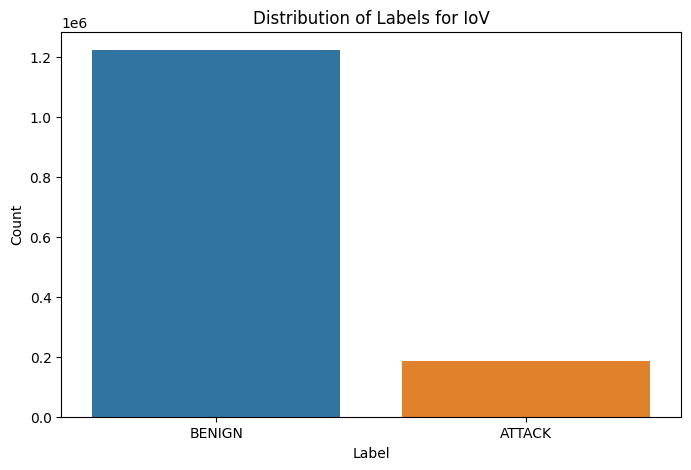

In [9]:
# Plot the distribution of labels
plt.figure(figsize=(8, 5))
sns.countplot(data=df2, x='label')
plt.title('Distribution of Labels for IoV')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

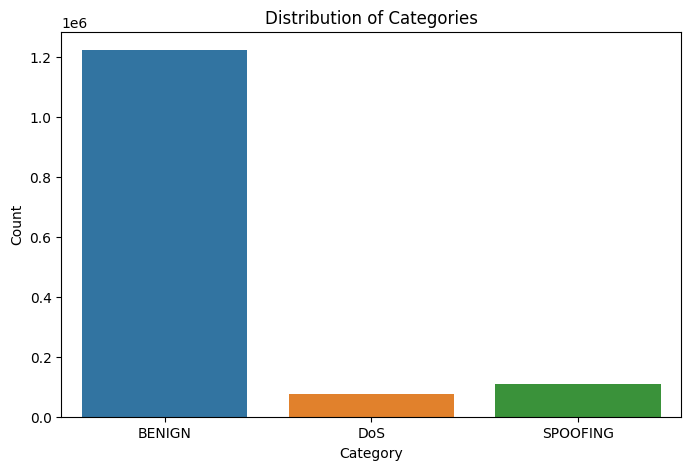

In [10]:
# Plot the distribution of categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df2, x='category')
plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

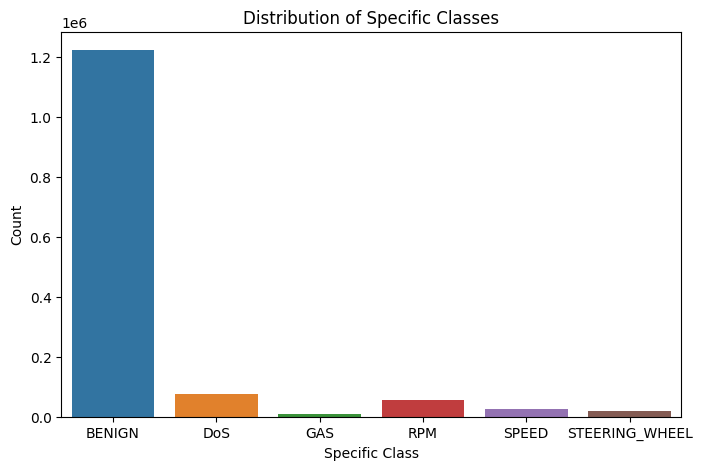

In [11]:
# Plot the distribution of specific classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df2, x='specific_class')
plt.title('Distribution of Specific Classes')
plt.xlabel('Specific Class')
plt.ylabel('Count')
plt.show()

In [12]:
data_columns = ['DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']

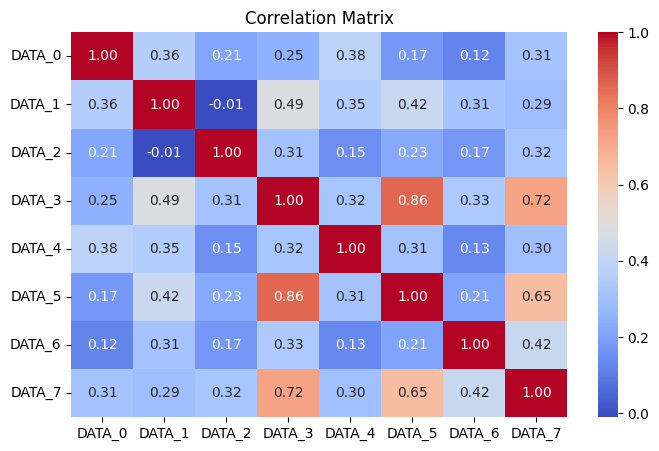

In [19]:
corr_matrix = df2[data_columns].corr()

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55450
           1       1.00      1.00      1.00    367016

    accuracy                           1.00    422466
   macro avg       1.00      1.00      1.00    422466
weighted avg       1.00      1.00      1.00    422466



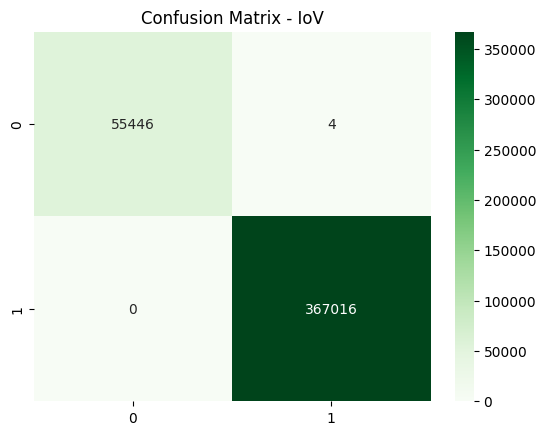

In [14]:
X = df2.drop(['ID', 'label', 'category', 'specific_class'], axis=1)
y = df2["label"]
#y = df2['label'].apply(lambda x: 1 if x == 'ATTACK' else 0)

# Encode string labels
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - IoV")
plt.show()

In [15]:
# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [16]:
# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55450
           1       1.00      1.00      1.00    367016

    accuracy                           1.00    422466
   macro avg       1.00      1.00      1.00    422466
weighted avg       1.00      1.00      1.00    422466

ROC-AUC Score: 0.9999993105019729


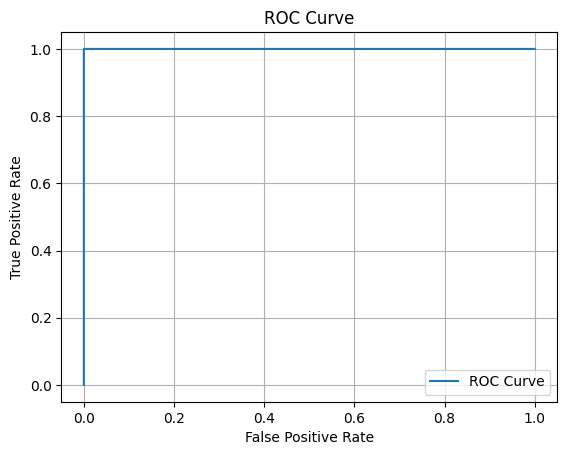

In [17]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

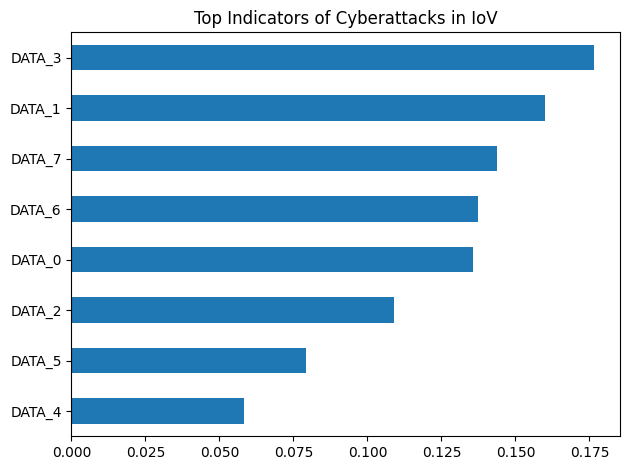

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', title='Top Indicators of Cyberattacks in IoV')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()